<a href="https://colab.research.google.com/github/suvarnaj3/nsl-kdd-robust-ids/blob/main/NSL_KDD_IDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget -q https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt
!wget -q https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [2]:
import pandas as pd

In [3]:
columns = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "attack",
    "difficulty"
]

In [4]:
train_df = pd.read_csv(
    "KDDTrain+.txt",
    names=columns
)

test_df = pd.read_csv(
    "KDDTest+.txt",
    names=columns
)

In [5]:
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (125973, 43)
Testing shape: (22544, 43)


In [6]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [7]:
train_df["attack"].value_counts()

,count
attack,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892


In [8]:
train_df["binary_target"] = (train_df["attack"] != "normal").astype(int)

train_df["binary_target"].value_counts()

,count
binary_target,
0,67343
1,58630


In [9]:
train_df["binary_target"].value_counts(normalize=True) * 100

,proportion
binary_target,
0,53.458281
1,46.541719


In [10]:
print("Normal:", (train_df["binary_target"] == 0).sum())
print("Attack:", (train_df["binary_target"] == 1).sum())

Normal: 67343
Attack: 58630


In [11]:
X = train_df.drop(columns=["attack", "difficulty", "binary_target"])
y = train_df["binary_target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (125973, 41)
y shape: (125973,)


In [12]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

Categorical features:
['protocol_type', 'service', 'flag']

Number of categorical features: 3
Number of numerical features: 38


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (100778, 41)
Validation: (25195, 41)


In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [16]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

print("Original features:", X_train.shape[1])
print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)

Original features: 41
Processed training shape: (100778, 121)
Processed validation shape: (25195, 121)


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_processed, y_train)

y_val_pred = dt_model.predict(X_val_processed)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall   :", recall_score(y_val, y_val_pred))
print("F1 Score :", f1_score(y_val, y_val_pred))

Decision Tree Results
---------------------
Accuracy : 0.9983726929946418
Precision: 0.9978696207925011
Recall   : 0.9986355108306327
F1 Score : 0.9982524189079749


[[13444    25]
 [   16 11710]]


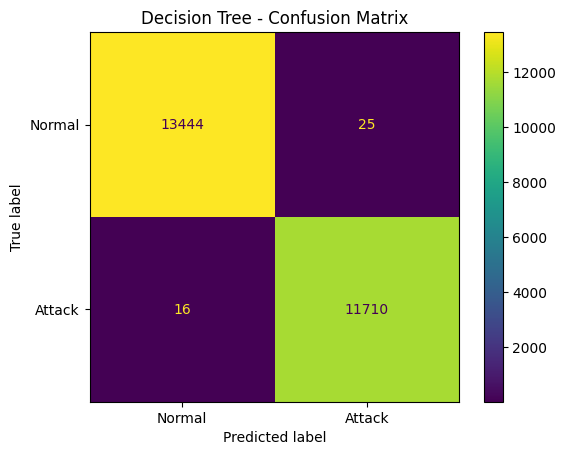

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Attack"]
)

disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [19]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(X_train_processed, y_train)

svm_val_pred = svm_model.predict(X_val_processed)

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("SVM Results")
print("-----------")
print("Accuracy :", accuracy_score(y_val, svm_val_pred))
print("Precision:", precision_score(y_val, svm_val_pred))
print("Recall   :", recall_score(y_val, svm_val_pred))
print("F1 Score :", f1_score(y_val, svm_val_pred))

SVM Results
-----------
Accuracy : 0.9927763445128002
Precision: 0.9910668708524758
Recall   : 0.9934333958724203
F1 Score : 0.9922487223168655


In [21]:
from sklearn.metrics import confusion_matrix

svm_cm = confusion_matrix(y_val, svm_val_pred)

print(svm_cm)

[[13364   105]
 [   77 11649]]


In [22]:
dt_train_pred = dt_model.predict(X_train_processed)

print("Decision Tree")
print("Training accuracy:",
      accuracy_score(y_train, dt_train_pred))

print("Validation accuracy:",
      accuracy_score(y_val, y_val_pred))

Decision Tree
Training accuracy: 0.9999503859969437
Validation accuracy: 0.9983726929946418


In [23]:
test_df["binary_target"] = (test_df["attack"] != "normal").astype(int)

X_test = test_df.drop(
    columns=["attack", "difficulty", "binary_target"]
)

y_test = test_df["binary_target"]

print("Test shape:", X_test.shape)
print("Test target shape:", y_test.shape)

Test shape: (22544, 41)
Test target shape: (22544,)


In [25]:
X_test_processed = preprocessor.transform(X_test)

print("Processed test shape:", X_test_processed.shape)

Processed test shape: (22544, 121)


In [26]:
dt_test_pred = dt_model.predict(X_test_processed)

print("Decision Tree - KDDTest+")
print("-------------------------")
print("Accuracy :", accuracy_score(y_test, dt_test_pred))
print("Precision:", precision_score(y_test, dt_test_pred))
print("Recall   :", recall_score(y_test, dt_test_pred))
print("F1 Score :", f1_score(y_test, dt_test_pred))

Decision Tree - KDDTest+
-------------------------
Accuracy : 0.7938697657913414
Precision: 0.9136850616535274
Recall   : 0.7044338813995169
F1 Score : 0.7955295463545563


In [27]:
svm_test_pred = svm_model.predict(X_test_processed)

print("SVM - KDDTest+")
print("---------------")
print("Accuracy :", accuracy_score(y_test, svm_test_pred))
print("Precision:", precision_score(y_test, svm_test_pred))
print("Recall   :", recall_score(y_test, svm_test_pred))
print("F1 Score :", f1_score(y_test, svm_test_pred))

SVM - KDDTest+
---------------
Accuracy : 0.7700053229240597
Precision: 0.9603900794606308
Recall   : 0.6216005610535339
F1 Score : 0.7547187662614125


In [28]:
print("KDDTrain+")
print(train_df["binary_target"].value_counts())
print(train_df["binary_target"].value_counts(normalize=True) * 100)

print("\nKDDTest+")
print(test_df["binary_target"].value_counts())
print(test_df["binary_target"].value_counts(normalize=True) * 100)

KDDTrain+
binary_target
0    67343
1    58630
Name: count, dtype: int64
binary_target
0    53.458281
1    46.541719
Name: proportion, dtype: float64

KDDTest+
binary_target
1    12833
0     9711
Name: count, dtype: int64
binary_target
1    56.924237
0    43.075763
Name: proportion, dtype: float64


In [29]:
from sklearn.metrics import confusion_matrix

dt_test_cm = confusion_matrix(y_test, dt_test_pred)

print("Decision Tree - KDDTest+")
print(dt_test_cm)

Decision Tree - KDDTest+
[[8857  854]
 [3793 9040]]


In [30]:
svm_test_cm = confusion_matrix(y_test, svm_test_pred)

print("\nSVM - KDDTest+")
print(svm_test_cm)


SVM - KDDTest+
[[9382  329]
 [4856 7977]]


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

rf_val_pred = rf_model.predict(X_val_processed)

In [32]:
print("Random Forest - Validation")
print("--------------------------")
print("Accuracy :", accuracy_score(y_val, rf_val_pred))
print("Precision:", precision_score(y_val, rf_val_pred))
print("Recall   :", recall_score(y_val, rf_val_pred))
print("F1 Score :", f1_score(y_val, rf_val_pred))

Random Forest - Validation
--------------------------
Accuracy : 0.9989680492161143
Precision: 0.9994024244493768
Recall   : 0.9983796691113764
F1 Score : 0.9988907849829352


In [33]:
rf_test_pred = rf_model.predict(X_test_processed)

print("Random Forest - KDDTest+")
print("------------------------")
print("Accuracy :", accuracy_score(y_test, rf_test_pred))
print("Precision:", precision_score(y_test, rf_test_pred))
print("Recall   :", recall_score(y_test, rf_test_pred))
print("F1 Score :", f1_score(y_test, rf_test_pred))

Random Forest - KDDTest+
------------------------
Accuracy : 0.7744410929737402
Precision: 0.9688937303316388
Recall   : 0.6237824359074262
F1 Score : 0.7589476179189382


In [34]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_processed, y_train)

# Validation
xgb_val_pred = xgb_model.predict(X_val_processed)

print("XGBoost - Validation")
print("--------------------")
print("Accuracy :", accuracy_score(y_val, xgb_val_pred))
print("Precision:", precision_score(y_val, xgb_val_pred))
print("Recall   :", recall_score(y_val, xgb_val_pred))
print("F1 Score :", f1_score(y_val, xgb_val_pred))

# KDDTest+
xgb_test_pred = xgb_model.predict(X_test_processed)

print("\nXGBoost - KDDTest+")
print("------------------")
print("Accuracy :", accuracy_score(y_test, xgb_test_pred))
print("Precision:", precision_score(y_test, xgb_test_pred))
print("Recall   :", recall_score(y_test, xgb_test_pred))
print("F1 Score :", f1_score(y_test, xgb_test_pred))

XGBoost - Validation
--------------------
Accuracy : 0.9988886683865846
Precision: 0.9989762839105955
Recall   : 0.9986355108306327
F1 Score : 0.998805868304333

XGBoost - KDDTest+
------------------
Accuracy : 0.8008782824698367
Precision: 0.9690802788396672
Recall   : 0.6716278344892075
F1 Score : 0.7933907120173057


In [35]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ("dt", DecisionTreeClassifier(random_state=42)),
        ("svm", SVC(kernel="rbf", random_state=42)),
        ("rf", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )),
        ("xgb", XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            eval_metric="logloss"
        ))
    ],
    voting="hard"
)

voting_model.fit(X_train_processed, y_train)

# Validation
voting_val_pred = voting_model.predict(X_val_processed)

print("Voting Ensemble - Validation")
print("-----------------------------")
print("Accuracy :", accuracy_score(y_val, voting_val_pred))
print("Precision:", precision_score(y_val, voting_val_pred))
print("Recall   :", recall_score(y_val, voting_val_pred))
print("F1 Score :", f1_score(y_val, voting_val_pred))

# KDDTest+
voting_test_pred = voting_model.predict(X_test_processed)

print("\nVoting Ensemble - KDDTest+")
print("---------------------------")
print("Accuracy :", accuracy_score(y_test, voting_test_pred))
print("Precision:", precision_score(y_test, voting_test_pred))
print("Recall   :", recall_score(y_test, voting_test_pred))
print("F1 Score :", f1_score(y_test, voting_test_pred))

Voting Ensemble - Validation
-----------------------------
Accuracy : 0.9987695971422902
Precision: 0.9995728321230244
Recall   : 0.9977827050997783
F1 Score : 0.9986769664120183

Voting Ensemble - KDDTest+
---------------------------
Accuracy : 0.774973385379702
Precision: 0.9678080540149505
Recall   : 0.6254967661497701
F1 Score : 0.7598807213518247


In [36]:
dt_weighted = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

dt_weighted.fit(X_train_processed, y_train)

# Validation
dt_weighted_val_pred = dt_weighted.predict(X_val_processed)

print("Weighted Decision Tree - Validation")
print("-----------------------------------")
print("Accuracy :", accuracy_score(y_val, dt_weighted_val_pred))
print("Precision:", precision_score(y_val, dt_weighted_val_pred))
print("Recall   :", recall_score(y_val, dt_weighted_val_pred))
print("F1 Score :", f1_score(y_val, dt_weighted_val_pred))

# KDDTest+
dt_weighted_test_pred = dt_weighted.predict(X_test_processed)

print("\nWeighted Decision Tree - KDDTest+")
print("---------------------------------")
print("Accuracy :", accuracy_score(y_test, dt_weighted_test_pred))
print("Precision:", precision_score(y_test, dt_weighted_test_pred))
print("Recall   :", recall_score(y_test, dt_weighted_test_pred))
print("F1 Score :", f1_score(y_test, dt_weighted_test_pred))

Weighted Decision Tree - Validation
-----------------------------------
Accuracy : 0.998571145068466
Precision: 0.9979553586641676
Recall   : 0.9989766331229746
F1 Score : 0.9984657347425844

Weighted Decision Tree - KDDTest+
---------------------------------
Accuracy : 0.8270049680624556
Precision: 0.9531297555037029
Recall   : 0.7320969375827944
F1 Score : 0.8281181137064786


In [40]:
def perturb_raw_data(df, percentage, random_state=42):
    rng = np.random.default_rng(random_state)

    df_perturbed = df.copy()

    for column in numerical_features:
        std = df[column].std()
        noise = rng.normal(
            loc=0,
            scale=percentage * std,
            size=len(df)
        )

        df_perturbed[column] = df[column] + noise

    return df_perturbed

In [41]:
noise_levels = [0, 0.05, 0.10, 0.20, 0.30]

robustness_results = []

for noise in noise_levels:

    perturbed_test = perturb_raw_data(
        X_test,
        percentage=noise,
        random_state=42
    )

    perturbed_processed = preprocessor.transform(perturbed_test)

    predictions = dt_weighted.predict(perturbed_processed)

    robustness_results.append({
        "Noise Level": f"{int(noise * 100)}%",
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions)
    })

robustness_df = pd.DataFrame(robustness_results)

robustness_df

,Noise Level,Accuracy,Precision,Recall,F1
0,0%,0.827005,0.953130,0.732097,0.828118
1,5%,0.660930,0.835858,0.503156,0.628174
2,10%,0.624423,0.748012,0.513052,0.608643
3,20%,0.588139,0.676447,0.529962,0.594311
4,30%,0.578291,0.655362,0.546638,0.596083


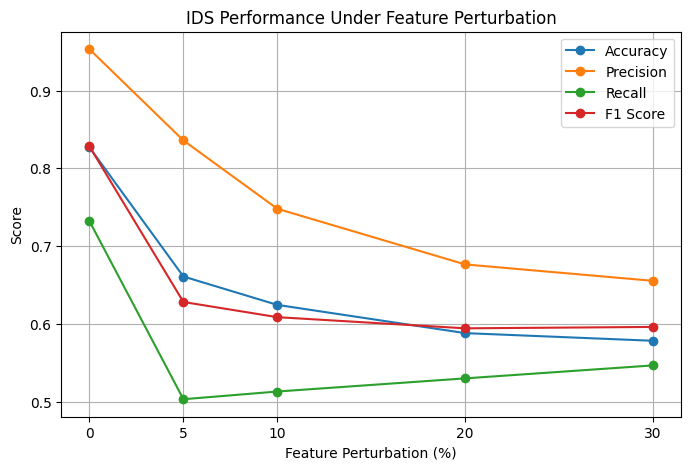

In [42]:
import matplotlib.pyplot as plt

noise_percent = [0, 5, 10, 20, 30]

plt.figure(figsize=(8, 5))

plt.plot(
    noise_percent,
    robustness_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    noise_percent,
    robustness_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    noise_percent,
    robustness_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    noise_percent,
    robustness_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Feature Perturbation (%)")
plt.ylabel("Score")
plt.title("IDS Performance Under Feature Perturbation")
plt.xticks(noise_percent)
plt.legend()
plt.grid(True)
plt.show()